In [2]:
!pip install fredapi

In [4]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 4.4 MB/s eta 0:00:00


FRED API 키를 입력하세요: f75d683dda2053416b64caae44e1bfb2
FRED에서 데이터를 가져오는 중입니다...
데이터 로딩 성공!
              6M    1Y    2Y    5Y    7Y   10Y
1995-01-03  6.66  7.23  7.73  7.88  7.91  7.88
1995-01-04  6.57  7.15  7.62  7.81  7.82  7.82
1995-01-05  6.61  7.32  7.66  7.87  7.89  7.88
1995-01-06  6.61  7.26  7.64  7.87  7.89  7.87
1995-01-09  6.67  7.27  7.68  7.90  7.92  7.89

--- STEP 1: 전체 기간 PCA 분석 시작 ---


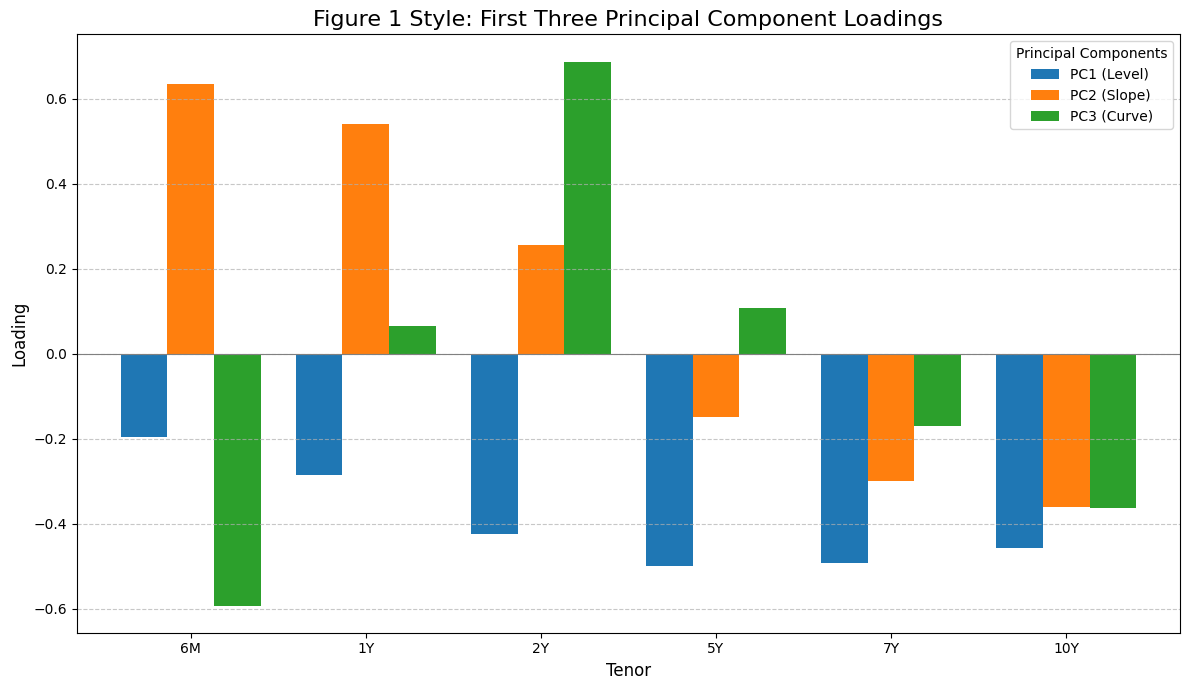

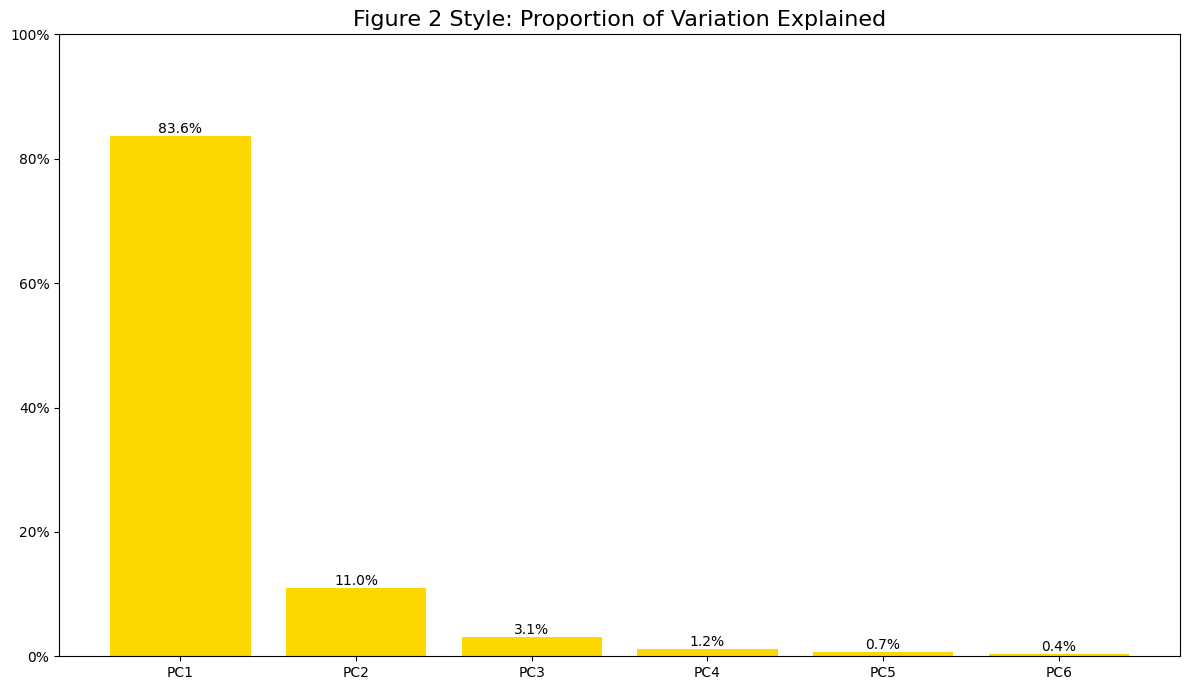

--- STEP 1: 전체 기간 PCA 분석 완료 ---


--- STEP 2: 롤링 윈도우 PCA 분석 시작 ---


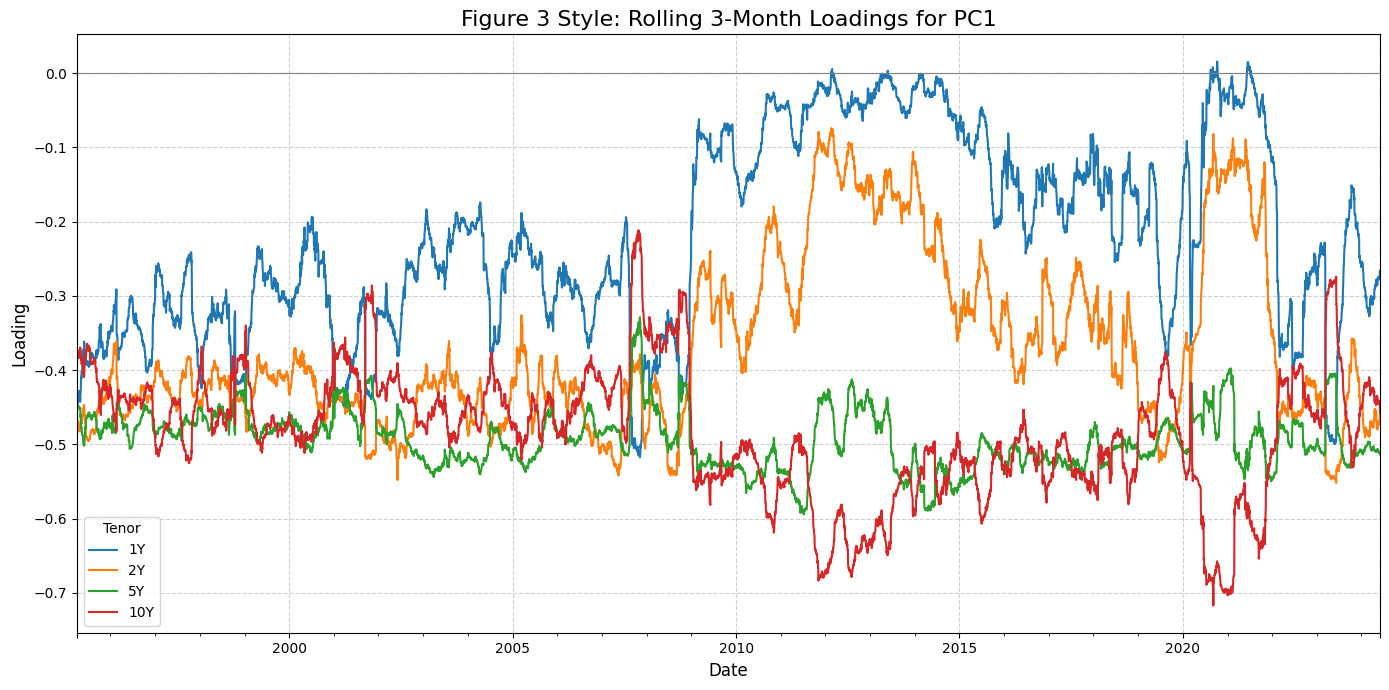

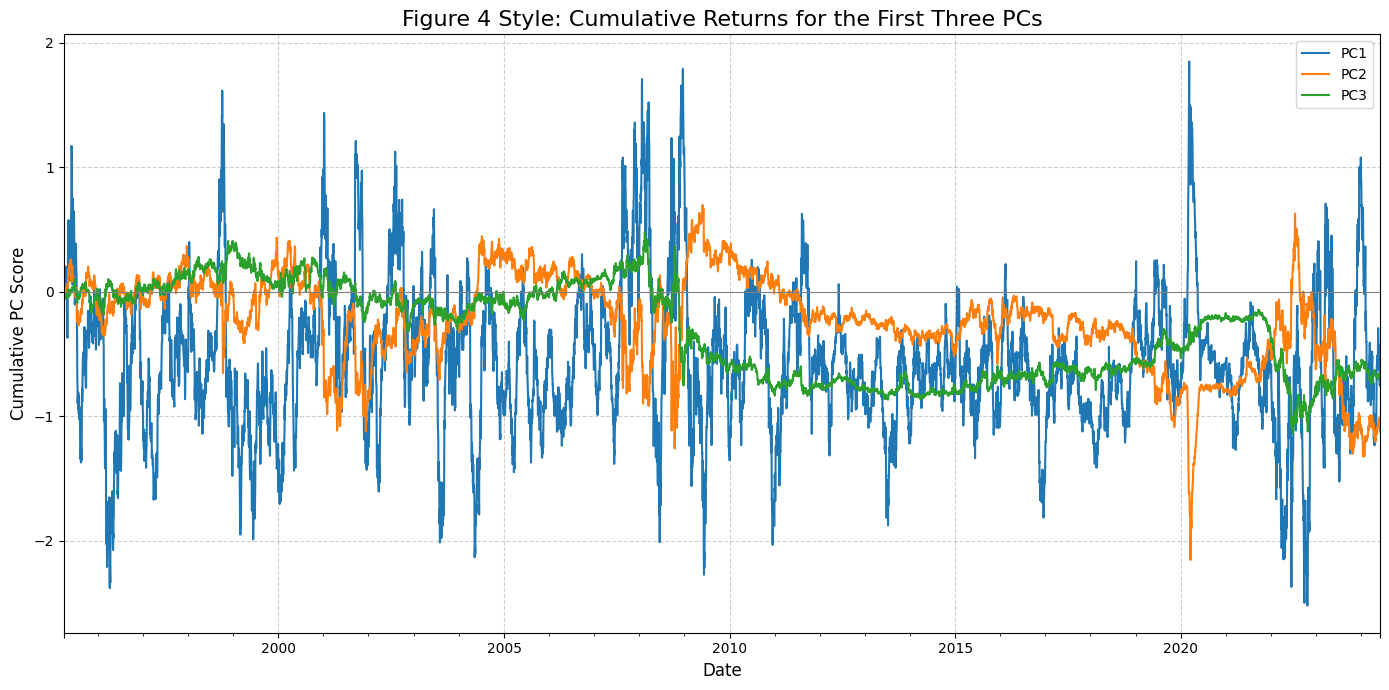

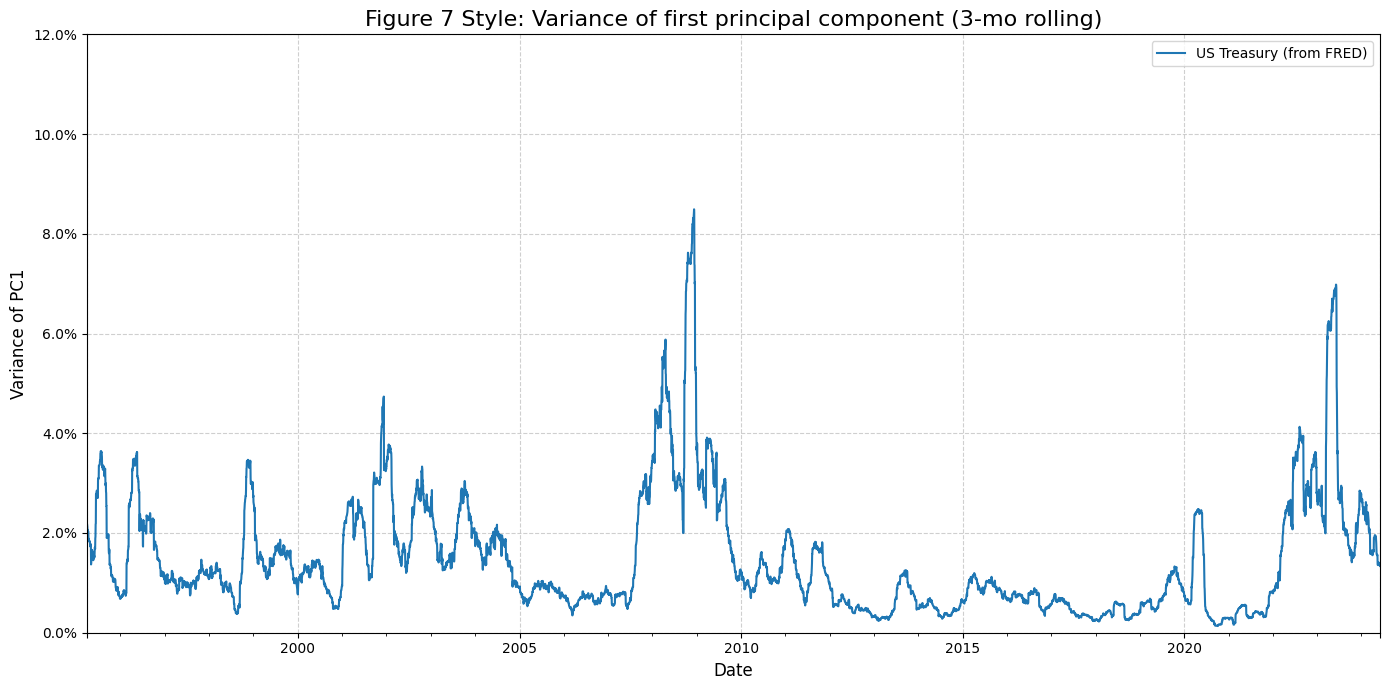

--- STEP 2: 롤링 윈도우 PCA 분석 완료 ---

--- STEP 3: HMM 레짐 분석 시작 ---
고변동성 레짐(State 1) 평균 Eigenvalue: 0.0264
저변동성 레짐(State 0) 평균 Eigenvalue: 0.0075


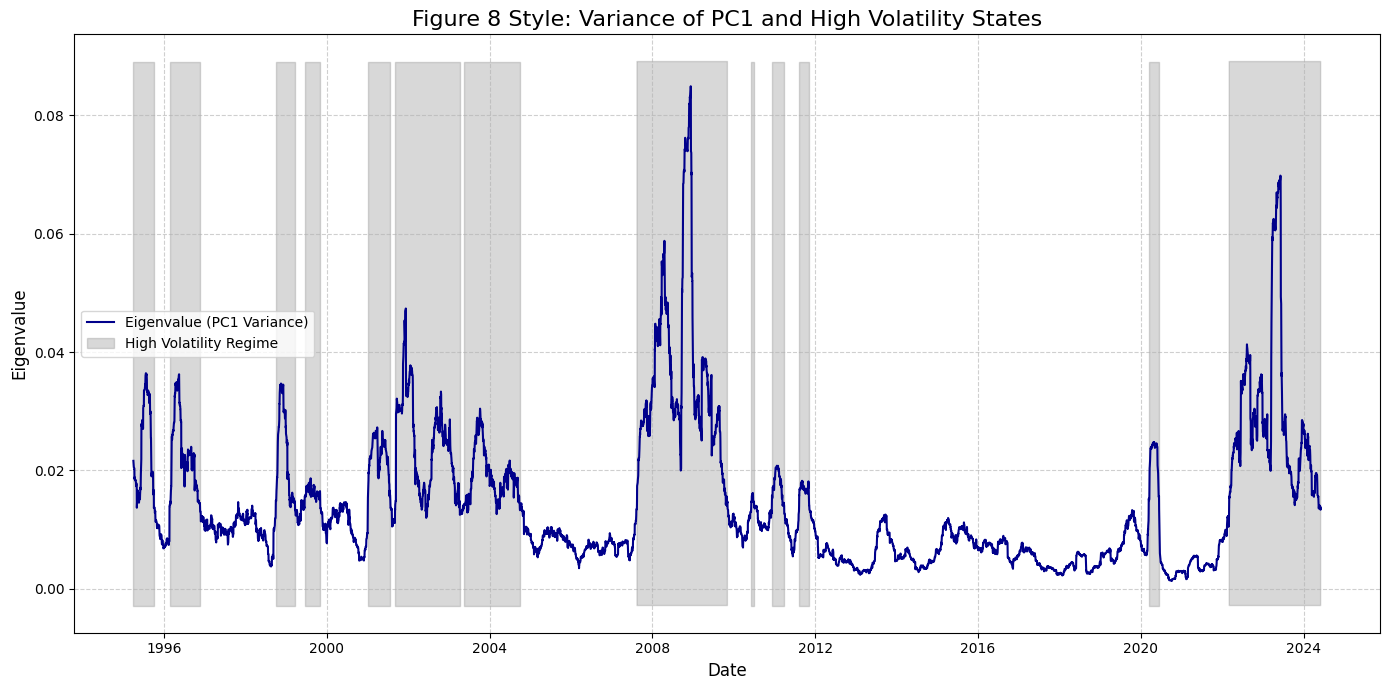

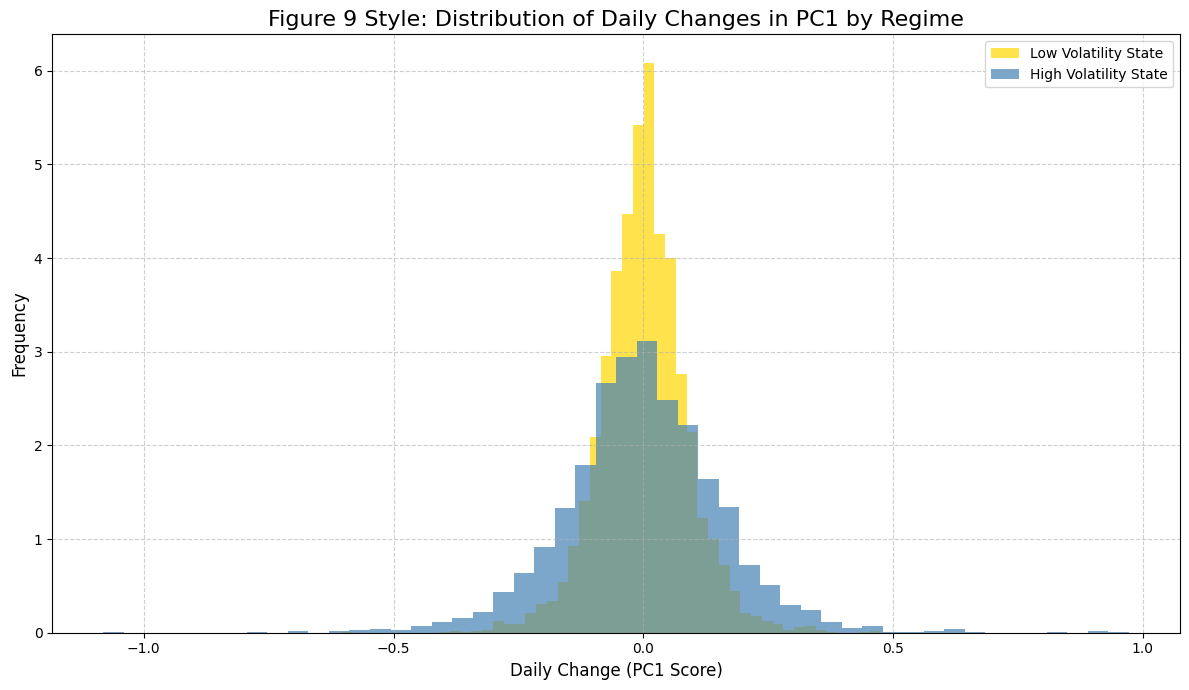

--- STEP 3: HMM 레짐 분석 완료 ---


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from fredapi import Fred
from hmmlearn import hmm

# --- STEP 0: 데이터 가져오기 (FRED API 사용) ---
def fetch_fred_data(api_key):
    """
    FRED API를 사용하여 미국 국채 금리 데이터를 가져옵니다.
    논문에 명시된 만기와 유사한 FRED 시리즈 ID를 사용합니다.
    """
    print("FRED에서 데이터를 가져오는 중입니다...")
    fred = Fred(api_key=api_key)

    series_map = {
        'DGS6MO': '6M', 'DGS1': '1Y', 'DGS2': '2Y',
        'DGS5': '5Y', 'DGS7': '7Y', 'DGS10': '10Y'
    }

    start_date = '1995-01-01'
    end_date = '2024-05-31'

    try:
        df_list = [fred.get_series(series_id, start_date, end_date) for series_id in series_map.keys()]
        df = pd.concat(df_list, axis=1)
        df.columns = list(series_map.values())
        df.ffill(inplace=True)
        df.dropna(inplace=True)
        print("데이터 로딩 성공!")
        print(df.head())
        return df
    except Exception as e:
        print(f"데이터 로딩 중 오류가 발생했습니다: {e}")
        print("유효한 FRED API 키를 입력했는지 확인해주세요.")
        return None

# --- 함수 수정 ---
def align_eigenvectors(pca, reference_vector=None):
    """
    PCA 결과의 부호를 일관성 있게 조정합니다.
    """
    components = pca.components_.copy()
    if reference_vector is None:
        if np.sum(components[0]) > 0:
            components[0] = -components[0]
        if components.shape[0] > 1 and (components[1, 0] < 0 or components[1, -1] > 0):
             components[1] = -components[1]
        if components.shape[0] > 2 and components[2, len(components[2])//2] < 0:
            components[2] = -components[2]
    else:
        for i in range(min(components.shape[0], reference_vector.shape[0])):
            if np.dot(components[i], reference_vector[i]) < 0:
                components[i] = -components[i]
    return components

def plot_figure1_loadings(pca_components, tenors):
    """논문의 Figure 1: 첫 세 개 주성분의 로딩 시각화"""
    fig, ax = plt.subplots(figsize=(12, 7))
    pc_labels = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curve)']
    n_components = min(3, pca_components.shape[0])
    df_loadings = pd.DataFrame(pca_components[:n_components, :].T, index=tenors, columns=pc_labels)
    df_loadings.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title('Figure 1 Style: First Three Principal Component Loadings', fontsize=16)
    ax.set_xlabel('Tenor', fontsize=12)
    ax.set_ylabel('Loading', fontsize=12)
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.legend(title='Principal Components')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_figure2_explained_variance(pca):
    """논문의 Figure 2: 각 주성분이 설명하는 분산 비율 시각화"""
    fig, ax = plt.subplots(figsize=(12, 7))
    explained_variance_ratio = pca.explained_variance_ratio_
    pc_labels = [f'PC{i+1}' for i in range(len(explained_variance_ratio))]
    bars = ax.bar(pc_labels, explained_variance_ratio, color='gold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval*100:.1f}%', ha='center', va='bottom')
    ax.set_title('Figure 2 Style: Proportion of Variation Explained', fontsize=16)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

def plot_figure3_rolling_loadings(df_loadings):
    """논문의 Figure 3: PC1의 롤링 로딩 시각화"""
    fig, ax = plt.subplots(figsize=(14, 7))
    tenors_to_plot = ['1Y', '2Y', '5Y', '10Y']
    df_loadings[tenors_to_plot].plot(ax=ax)
    ax.set_title('Figure 3 Style: Rolling 3-Month Loadings for PC1', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Loading', fontsize=12)
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.legend(title='Tenor')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_figure4_cumulative_returns(df_pc_returns):
    """논문의 Figure 4: 주성분들의 누적 수익률 시각화"""
    fig, ax = plt.subplots(figsize=(14, 7))
    df_pc_returns.cumsum().plot(ax=ax)
    ax.set_title('Figure 4 Style: Cumulative Returns for the First Three PCs', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Cumulative PC Score', fontsize=12)
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- 함수 수정 ---
def plot_figure7_rolling_variance(series_eigenvalues):
    """논문의 Figure 7: PC1의 롤링 분산(고유값) 시각화"""
    fig, ax = plt.subplots(figsize=(14, 7))

    # Y축을 퍼센트로 포맷팅 (e.g., 0.08 -> 8%)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    series_eigenvalues.plot(ax=ax, label='US Treasury (from FRED)')

    ax.set_title('Figure 7 Style: Variance of first principal component (3-mo rolling)', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Variance of PC1', fontsize=12)
    ax.legend()
    # Y축 범위를 논문과 유사하게 조정
    ax.set_ylim(bottom=0, top=0.12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- STEP 1 & 2 함수 (기존과 동일, 반환값 추가) ---

def run_step1_full_pca(yield_data):
    """STEP 1: 전체 기간에 대한 PCA 분석 수행"""
    print("\n--- STEP 1: 전체 기간 PCA 분석 시작 ---")
    daily_changes = yield_data.diff().dropna()

    # *** 수정: StandardScaler 제거. 공분산 행렬을 직접 사용. ***
    pca = PCA()
    pca.fit(daily_changes.values) # .values를 사용하여 numpy array로 전달

    aligned_components = align_eigenvectors(pca)
    plot_figure1_loadings(aligned_components, yield_data.columns)
    plot_figure2_explained_variance(pca)
    print("--- STEP 1: 전체 기간 PCA 분석 완료 ---\n")

# --- 함수 수정 ---
def run_step2_rolling_pca(yield_data):
    """STEP 2: 롤링 윈도우 PCA 분석 수행. HMM을 위해 결과 반환"""
    print("\n--- STEP 2: 롤링 윈도우 PCA 분석 시작 ---")
    daily_changes = yield_data.diff().dropna()
    window_size = 63

    rolling_loadings_pc1 = []
    rolling_eigenvalues_pc1 = []
    rolling_pc_returns = []
    prev_components = None

    for i in range(window_size, len(daily_changes)):
        window_data = daily_changes.iloc[i-window_size:i]

        # *** 수정: StandardScaler 제거 ***
        pca = PCA(n_components=3)
        pc_scores = pca.fit_transform(window_data.values)

        aligned_components = align_eigenvectors(pca, reference_vector=prev_components)

        if prev_components is not None:
            for j in range(aligned_components.shape[0]):
                if np.dot(pca.components_[j], prev_components[j]) < 0:
                    pc_scores[:, j] = -pc_scores[:, j]
        else:
            if np.sum(pca.components_[0]) > 0: pc_scores[:, 0] = -pc_scores[:, 0]
            if pca.components_[1, 0] < 0 or pca.components_[1, -1] > 0: pc_scores[:, 1] = -pc_scores[:, 1]
            if pca.components_[2, len(pca.components_[2])//2] < 0: pc_scores[:, 2] = -pc_scores[:, 2]

        prev_components = aligned_components.copy()
        rolling_loadings_pc1.append(aligned_components[0])
        rolling_eigenvalues_pc1.append(pca.explained_variance_[0])
        rolling_pc_returns.append(pc_scores[-1, :])

    dates_for_rolling = daily_changes.index[window_size:]
    df_loadings = pd.DataFrame(rolling_loadings_pc1, index=dates_for_rolling, columns=yield_data.columns)
    df_eigenvalues = pd.Series(rolling_eigenvalues_pc1, index=dates_for_rolling, name="Eigenvalue_PC1")
    df_pc_returns = pd.DataFrame(rolling_pc_returns, index=dates_for_rolling, columns=['PC1', 'PC2', 'PC3'])

    plot_figure3_rolling_loadings(df_loadings)
    plot_figure4_cumulative_returns(df_pc_returns)
    plot_figure7_rolling_variance(df_eigenvalues)

    print("--- STEP 2: 롤링 윈도우 PCA 분석 완료 ---")
    return df_eigenvalues, df_pc_returns

# --- STEP 3: HMM 레짐 분석 (신규 추가) ---

def run_step3_hmm_regime_detection(eigenvalues, pc_returns):
    """STEP 3: HMM을 이용한 레짐 식별 및 시각화"""
    print("\n--- STEP 3: HMM 레짐 분석 시작 ---")

    hmm_data = eigenvalues.values.reshape(-1, 1)
    model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=42)
    model.fit(hmm_data)
    hidden_states = model.predict(hmm_data)

    high_vol_state = np.argmax(model.means_)
    low_vol_state = 1 - high_vol_state
    print(f"고변동성 레짐(State {high_vol_state}) 평균 Eigenvalue: {model.means_[high_vol_state][0]:.4f}")
    print(f"저변동성 레짐(State {low_vol_state}) 평균 Eigenvalue: {model.means_[low_vol_state][0]:.4f}")

    df_regime = pd.DataFrame({
        'Eigenvalue': eigenvalues,
        'State': hidden_states,
        'PC1_Return': pc_returns['PC1']
    })

    plot_figure8_regimes(df_regime, high_vol_state)
    plot_figure9_distribution(df_regime, high_vol_state, low_vol_state)

    print("--- STEP 3: HMM 레짐 분석 완료 ---")

def plot_figure8_regimes(df_regime, high_vol_state):
    """논문의 Figure 8: 고유값과 HMM으로 식별된 고변동성 레짐 시각화"""
    fig, ax = plt.subplots(figsize=(14, 7))

    ax.plot(df_regime.index, df_regime['Eigenvalue'], label='Eigenvalue (PC1 Variance)', color='darkblue')
    ax.fill_between(df_regime.index, ax.get_ylim()[0], ax.get_ylim()[1],
                    where=(df_regime['State'] == high_vol_state),
                    color='grey', alpha=0.3, label='High Volatility Regime')

    ax.set_title('Figure 8 Style: Variance of PC1 and High Volatility States', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Eigenvalue', fontsize=12)
    ax.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_figure9_distribution(df_regime, high_vol_state, low_vol_state):
    """논문의 Figure 9: 레짐별 PC1 일별 변화량 분포 시각화"""
    fig, ax = plt.subplots(figsize=(12, 7))

    high_vol_returns = df_regime[df_regime['State'] == high_vol_state]['PC1_Return']
    low_vol_returns = df_regime[df_regime['State'] == low_vol_state]['PC1_Return']

    ax.hist(low_vol_returns, bins=50, density=True, alpha=0.7, label='Low Volatility State', color='gold')
    ax.hist(high_vol_returns, bins=50, density=True, alpha=0.7, label='High Volatility State', color='steelblue')

    ax.set_title('Figure 9 Style: Distribution of Daily Changes in PC1 by Regime', fontsize=16)
    ax.set_xlabel('Daily Change (PC1 Score)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    # --- FRED API 키 입력 ---
    my_fred_api_key = input("FRED API 키를 입력하세요: ")

    if not my_fred_api_key:
        print("API 키가 입력되지 않았습니다. 프로그램을 종료합니다.")
    else:
        # --- 데이터 로드 ---
        yield_data = fetch_fred_data(api_key=my_fred_api_key)

        if yield_data is not None:
            # --- 스텝 1 실행 ---
            run_step1_full_pca(yield_data)

            # --- 스텝 2 실행 및 결과 저장 ---
            eigenvalues, pc_returns = run_step2_rolling_pca(yield_data)

            # --- 스텝 3 실행 ---
            run_step3_hmm_regime_detection(eigenvalues, pc_returns)